In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import h5py
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
RAW_DATA_DIR = Path("/content/drive/MyDrive/pcam_project/raw")
OUTPUT_DIR = Path("/content/drive/MyDrive/pcam_project/processed_denoising_final")

print("Raw data path:", RAW_DATA_DIR)
print("Output path:", OUTPUT_DIR)

Raw data path: /content/drive/MyDrive/pcam_project/raw
Output path: /content/drive/MyDrive/pcam_project/processed_denoising_final


In [4]:
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / split / "clean").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "noisy").mkdir(parents=True, exist_ok=True)

print("Final folder structure created successfully.")

Final folder structure created successfully.


In [5]:
split_map = {
    "train": "camelyonpatch_level_2_split_train_x.h5",
    "val": "camelyonpatch_level_2_split_valid_x.h5",
    "test": "camelyonpatch_level_2_split_test_x.h5"
}

export_counts = {
    "train": 10000,
    "val": 2000,
    "test": 2000
}

sigma = 35

print("Export counts:", export_counts)
print("Sigma:", sigma)

Export counts: {'train': 10000, 'val': 2000, 'test': 2000}
Sigma: 35


In [6]:
def add_gaussian_noise(image, sigma=35):
    image = image.astype(np.float32)
    noise = np.random.normal(0, sigma, image.shape)
    noisy = image + noise
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return noisy

In [7]:
for split, filename in split_map.items():
    file_path = RAW_DATA_DIR / filename
    with h5py.File(file_path, "r") as f:
        print(f"{split}: shape={f['x'].shape}")

train: shape=(262144, 96, 96, 3)
val: shape=(32768, 96, 96, 3)
test: shape=(32768, 96, 96, 3)


In [8]:
for split, filename in split_map.items():
    file_path = RAW_DATA_DIR / filename
    count = export_counts[split]

    print(f"\nProcessing split: {split}")
    print(f"Reading from: {file_path}")
    print(f"Exporting {count} clean/noisy pairs...")

    with h5py.File(file_path, "r") as f:
        data = f["x"]

        for i in tqdm(range(count), desc=f"Exporting {split}"):
            clean_img = data[i]
            noisy_img = add_gaussian_noise(clean_img, sigma=sigma)

            clean_path = OUTPUT_DIR / split / "clean" / f"{split}_{i:05d}.png"
            noisy_path = OUTPUT_DIR / split / "noisy" / f"{split}_{i:05d}.png"

            Image.fromarray(clean_img).save(clean_path)
            Image.fromarray(noisy_img).save(noisy_path)

    print(f"Finished {split}")


Processing split: train
Reading from: /content/drive/MyDrive/pcam_project/raw/camelyonpatch_level_2_split_train_x.h5
Exporting 10000 clean/noisy pairs...


Exporting train: 100%|██████████| 10000/10000 [04:38<00:00, 35.94it/s]


Finished train

Processing split: val
Reading from: /content/drive/MyDrive/pcam_project/raw/camelyonpatch_level_2_split_valid_x.h5
Exporting 2000 clean/noisy pairs...


Exporting val: 100%|██████████| 2000/2000 [01:00<00:00, 32.93it/s]


Finished val

Processing split: test
Reading from: /content/drive/MyDrive/pcam_project/raw/camelyonpatch_level_2_split_test_x.h5
Exporting 2000 clean/noisy pairs...


Exporting test: 100%|██████████| 2000/2000 [01:01<00:00, 32.64it/s]

Finished test


In [9]:
for split in ["train", "val", "test"]:
    clean_files = list((OUTPUT_DIR / split / "clean").glob("*.png"))
    noisy_files = list((OUTPUT_DIR / split / "noisy").glob("*.png"))

    print(f"{split}: clean={len(clean_files)}, noisy={len(noisy_files)}")

train: clean=10000, noisy=10000
val: clean=2000, noisy=2000
test: clean=2000, noisy=2000


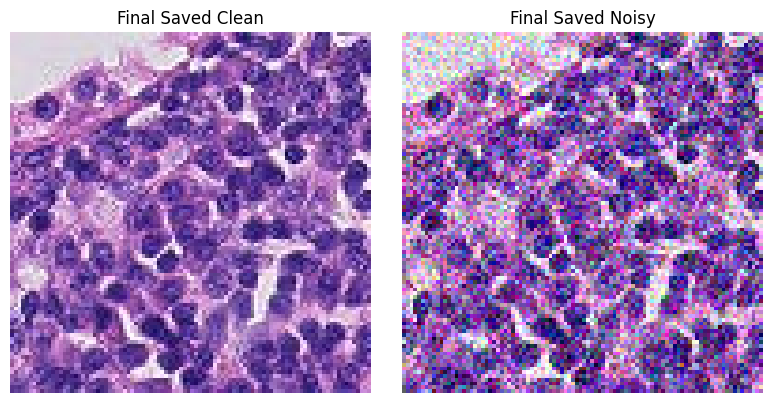

In [10]:
example_clean = Image.open(OUTPUT_DIR / "train" / "clean" / "train_00000.png")
example_noisy = Image.open(OUTPUT_DIR / "train" / "noisy" / "train_00000.png")

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(example_clean)
plt.title("Final Saved Clean")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(example_noisy)
plt.title("Final Saved Noisy")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
import os

def folder_size_mb(path):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for filename in filenames:
            fp = os.path.join(dirpath, filename)
            total += os.path.getsize(fp)
    return total / (1024 * 1024)

size_mb = folder_size_mb(OUTPUT_DIR)
print(f"Processed denoising dataset size: {size_mb:.2f} MB")

Processed denoising dataset size: 667.91 MB
